In [1]:
from IPython.display import display, HTML 
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [18]:
# import
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import mnist # mnist 데이터 셋
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from tensorflow.keras.models import Sequential, load_model, save_model
from tensorflow.keras.layers import Dense, Input, Dropout
from sklearn.model_selection import train_test_split # 데이터 분할(층화추출로)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from matplotlib import pyplot as plt # 학습과정 loss와 acc 시각화
# quiz에서는 scale조정, train_test_split 등을 추가

In [19]:
# 1. 데이터 셋
width = 28; height = 28
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

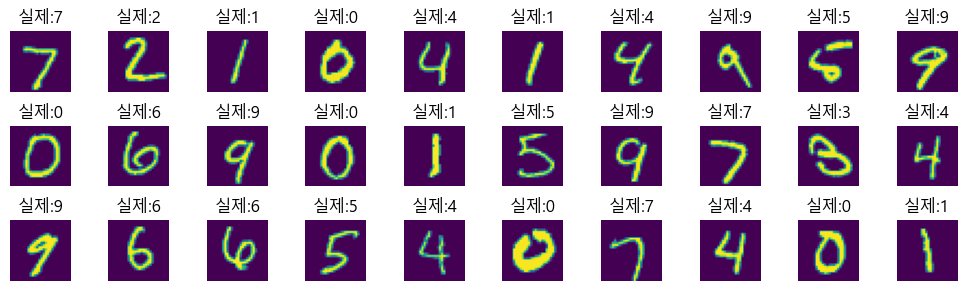

In [20]:
plt_row = 3
plt_col = 10
# plt.figure(figsize=(plt_col, plt_row))
plt.rcParams['figure.figsize'] = [plt_col, plt_row]
plt.rc('font', family='Malgun Gothic') # window에서 한글 시각화
# plt.rc('font', family='NanumBarunGothic') # 코랩에서 한글 시각화
fig, axes = plt.subplots(plt_row, plt_col)
# axes[0, 0].imshow(X_test[0].reshape(width, height))
# axes[0, 0].axis('off')
# title = '실제:{}'.format(y_test[0])
# axes[0, 0].set_title(title)
# plt.subplot_adjust(hspace=0.4, wspace=0.3)
for i in range(plt_row*plt_col):
    subax = axes[i//plt_col, i%plt_col] # // 몫연산자, % 나머지연산자
    subax.imshow(X_test[i].reshape(width, height))
    subax.axis('off')
    title = '실제:{}'.format(y_test[i])
    subax.set_title(title)
plt.tight_layout()

# 1. DNN

In [23]:
%%time
# 1. 데이터 생성 및 전처리
width = 28; height = 28
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_val = X_train[50000:]; y_val = y_train[50000:]
X_train = X_train[:50000]; y_train = y_train[:50000]
# 독립변수 (28,28) => 784 1차원 -> 실수형변환 -> 스케일조정
X_train = X_train.reshape(-1, width*height).astype('float32')/255.0
X_val   = X_val.reshape(-1, width*height).astype('float32')/255.0
X_test = X_test.reshape(-1, width*height).astype('float32')/255.0
# 타겟변수 원핫인코딩
Y_train = to_categorical(y_train)
Y_val   = to_categorical(y_val)
Y_test  = to_categorical(y_test)
X_train.shape, Y_train.shape, X_val.shape, Y_val.shape, X_test.shape, Y_test.shape

# 2.모델 구성
model = Sequential([
    Input(shape=(width*height,)),
    Dense(units=1024, activation='relu'),
    Dropout(0.3),
    Dense(units=512, activation='relu'),
    Dropout(0.2),
    Dense(units=256, activation='relu'),
    Dropout(0.1),
    Dense(units=10, activation='softmax')
])
# model.summary()
# 3. 학습 설정
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='adam',
             metrics=['accuracy'])
# 4. 학습

hist = model.fit(X_train, Y_train,
                epochs=50,
                validation_data=(X_val, Y_val),
                verbose=1) # 콜백함수

Epoch 1/50
1563/1563 [==============================] - 19s 12ms/step - loss: 0.2576 - accuracy: 0.9216 - val_loss: 0.1253 - val_accuracy: 0.9637
Epoch 2/50
1563/1563 [==============================] - 18s 12ms/step - loss: 0.1336 - accuracy: 0.9608 - val_loss: 0.1027 - val_accuracy: 0.9705
Epoch 3/50
1563/1563 [==============================] - 19s 12ms/step - loss: 0.1030 - accuracy: 0.9699 - val_loss: 0.0873 - val_accuracy: 0.9756
Epoch 4/50
1563/1563 [==============================] - 19s 12ms/step - loss: 0.0907 - accuracy: 0.9729 - val_loss: 0.1189 - val_accuracy: 0.9671
Epoch 5/50
1563/1563 [==============================] - 19s 12ms/step - loss: 0.0766 - accuracy: 0.9766 - val_loss: 0.0806 - val_accuracy: 0.9791
Epoch 6/50
1563/1563 [==============================] - 19s 12ms/step - loss: 0.0724 - accuracy: 0.9789 - val_loss: 0.0836 - val_accuracy: 0.9775
Epoch 7/50
1563/1563 [==============================] - 19s 12ms/step - loss: 0.0647 - accuracy: 0.9811 - val_loss: 0.0833 -

In [24]:
model.save('minst_dnn.h5')

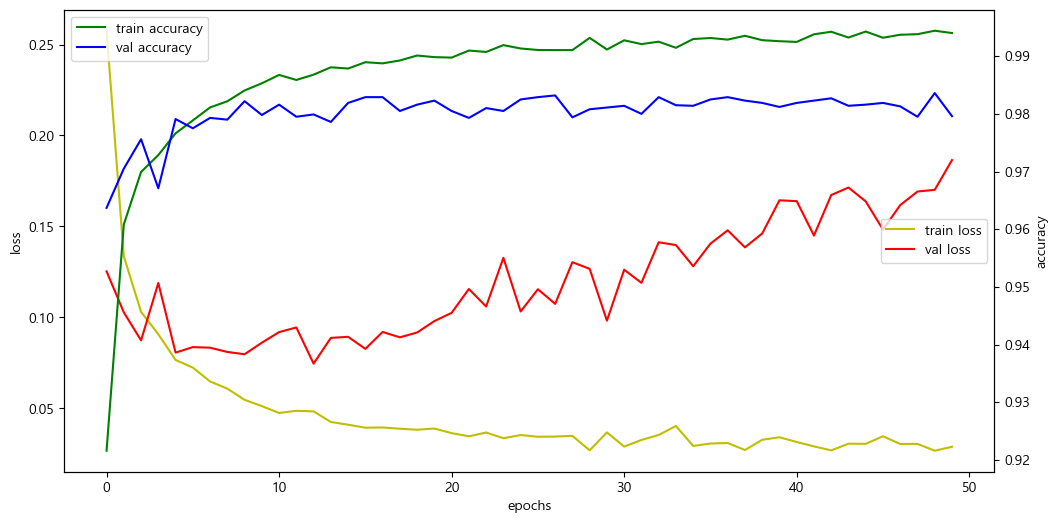

In [25]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

In [28]:
model.evaluate(X_test, Y_test)

313/313 [==============================] - 1s 5ms/step - loss: 0.1894 - accuracy: 0.9826


[0.1894107609987259, 0.9825999736785889]

In [27]:
# 혼동행렬
from sklearn.metrics import confusion_matrix
print('실제값 : ', y_test)
print('실제값 : ', np.argmax(Y_test, axis=1))
y_hat = model.predict(X_test).argmax(axis=1)
cmatrix = confusion_matrix(y_test, y_hat)
cmatrix

실제값 :  [7 2 1 ... 4 5 6]
실제값 :  [7 2 1 ... 4 5 6]
313/313 [==============================] - 1s 4ms/step


array([[ 972,    1,    0,    0,    0,    1,    3,    1,    2,    0],
       [   0, 1123,    1,    0,    0,    2,    3,    0,    6,    0],
       [   0,    1, 1020,    1,    1,    0,    1,    4,    4,    0],
       [   0,    0,    3, 1000,    0,    2,    0,    4,    1,    0],
       [   1,    1,    3,    0,  956,    0,    6,    2,    0,   13],
       [   3,    0,    0,   11,    1,  866,    6,    1,    3,    1],
       [   2,    2,    0,    0,    2,    2,  950,    0,    0,    0],
       [   1,    5,   11,    3,    1,    0,    0, 1001,    3,    3],
       [   0,    0,    3,    4,    3,    1,    1,    3,  957,    2],
       [   1,    3,    0,    4,    7,    3,    0,    4,    6,  981]],
      dtype=int64)

In [34]:
# 실제값과 예측값이 다른 갯수(방법1)
cnt = 0
for i, row in enumerate(cmatrix):
    for j, data in enumerate(row):
        if i!=j:
            cnt+=data
print('예측이 틀린 갯수 :', cnt)

예측이 틀린 갯수 : 174


In [35]:
# 실제값과 예측값이 다른 갯수(방법1)
cnt = 0
for y, h in zip(y_test, y_hat):
    if y!=h:
        cnt +=1
print('예측이 틀린 갯수 :', cnt)

예측이 틀린 갯수 : 174


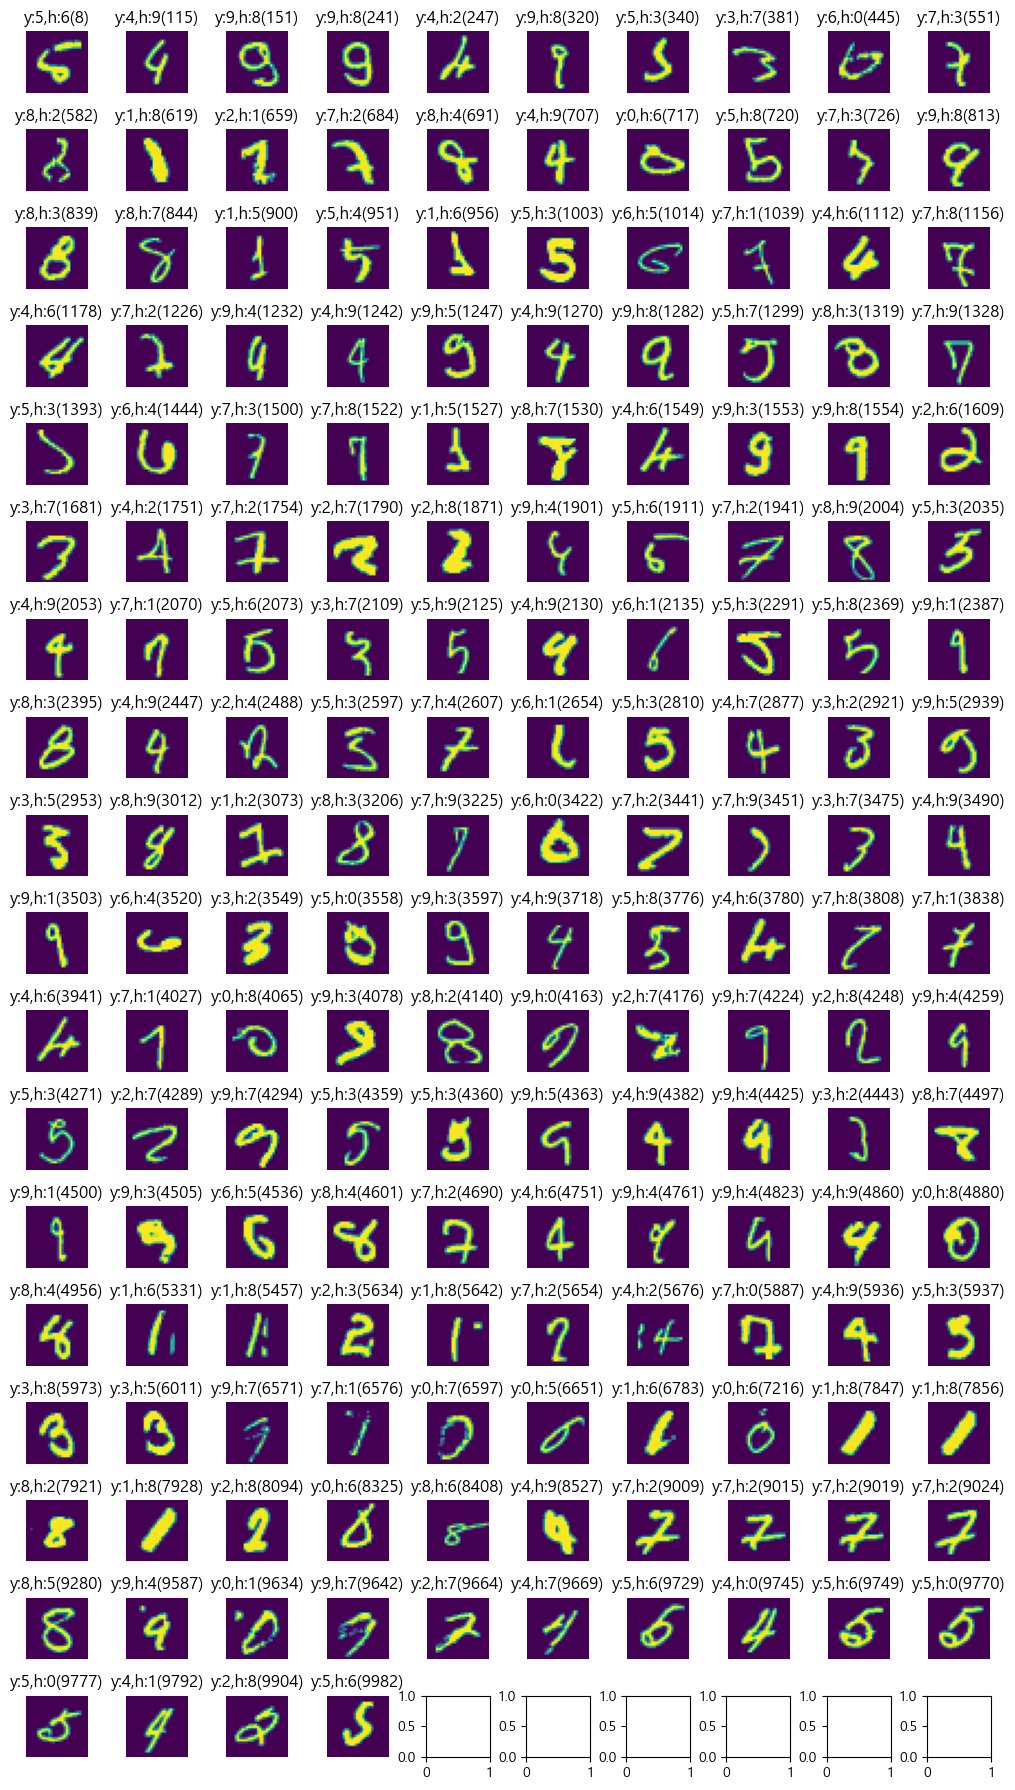

In [39]:
# CNN을 사용하여 예측이 틀린 데이터 출력(y_hat과 y_test가 다른 것들 174개)
plt_row = 18
plt_col = 10
plt.rcParams['figure.figsize'] = [plt_col, plt_row]
plt.rc('font', family='Malgun Gothic') # window에서 한글 시각화
# plt.rc('font', family='NanumBarunGothic') # 코랩에서 한글 시각화
fig, axes = plt.subplots(plt_row, plt_col)
plt.subplots_adjust(hspace=0.5, wspace=0.5)

i = 0 # y_hat과 y_test의 index => y_hat[i], y_test[i]를 비교
cnt = 0 # 이미지 출력 횟수
while (i<len(y_test)) & (cnt < plt_row*plt_col):
    if y_hat[i] == y_test[i]:
        i += 1
        continue

    subax = axes[cnt//plt_col, cnt%plt_col] # // 몫연산자, % 나머지연산자
    subax.imshow(X_test[i].reshape(width, height))
    subax.axis('off')
    title = 'y:{},h:{}({})'.format(y_test[i], y_hat[i], i)
    subax.set_title(title)
    cnt += 1 # 이미지 출력번호 증가
    i += 1 # index 증가
plt.tight_layout()

# CNN(컨볼루션 레이어 포함) - 교안 33page

In [40]:
%%time
# 1. 데이터 생성 및 전처리
width = 28; height = 28
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_val = X_train[50000:]; y_val = y_train[50000:]
X_train = X_train[:50000]; y_train = y_train[:50000]
# 독립변수 (28,28) => 784 1차원 -> 실수형변환 -> 스케일조정
X_train = X_train.reshape(-1, width*height).astype('float32')/255.0
X_val   = X_val.reshape(-1, width*height).astype('float32')/255.0
X_test = X_test.reshape(-1, width*height).astype('float32')/255.0
# 타겟변수 원핫인코딩
Y_train = to_categorical(y_train)
Y_val   = to_categorical(y_val)
Y_test  = to_categorical(y_test)
X_train.shape, Y_train.shape, X_val.shape, Y_val.shape, X_test.shape, Y_test.shape

CPU times: total: 453 ms
Wall time: 474 ms


((50000, 784),
 (50000, 10),
 (10000, 784),
 (10000, 10),
 (10000, 784),
 (10000, 10))

In [ ]:
# 2. 모델 생성